# 06. Evaluation Expansion

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features) and the models compared in 05_advanced_models.ipynb (`LinearRegression`, `RandomForest (max_depth=5)`, `XGBoost (tuned)`, `LightGBM (tuned)`).

R2 and RMSE tell us how a model does *on average in dollar terms*, but they're dominated by a handful of large-dollar errors on expensive properties (see 04_model_comparison.ipynb / 05_advanced_models.ipynb - RMSE was consistently much worse than MAE for the tree-based models). This notebook adds two percentage-based metrics that are easier to interpret business-wise and less skewed by a few extreme-dollar errors:

- **MAPE** (Mean Absolute Percentage Error): average of `|actual - predicted| / actual`, as a percentage
- **MdAPE** (Median Absolute Percentage Error): same idea, but the *median* instead of the mean - much less sensitive to a handful of badly-mispriced outliers

It also breaks results down **by price band**, to check directly whether the tree-based models' weakness really is concentrated in the high-price tail, as suspected in earlier notebooks.


In [37]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost "
    ) from e

try:
    from lightgbm import LGBMRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs lightgbm. Install with: pip install lightgbm"
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [38]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(141988, 115)


split
train    129964
test      12024
Name: count, dtype: int64

## 2. Separate features / target using the `split` column

Same pattern as the previous notebooks: `split == "train"` for training, `split == "test"` for the held-out final evaluation.

Feature column names are sanitized before use: several are one-hot columns from the multi-label `Flooring` encoding (02_preprocessing.ipynb section 5), e.g. `cat__Flooring_Bamboo,Carpet,Laminate`, and LightGBM's parser rejects feature names containing certain JSON special characters (`, : [ ] { } "`) - XGBoost and the other models tolerate them, but they're replaced with `_` here so every model in this notebook stays on identical column names.


In [39]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

def sanitize_feature_name(name):
    # LightGBM rejects these JSON special characters in feature names; the other models tolerate
    # them, but all models here are kept on identical (sanitized) column names to avoid any mismatch.
    return re.sub(r'[",:\[\]{}]', "_", name)

raw_feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]
sanitized_names = [sanitize_feature_name(c) for c in raw_feature_cols]

if len(set(sanitized_names)) != len(sanitized_names):
    # Extremely unlikely with this data, but guard against two different raw names colliding
    # onto the same sanitized name (e.g. "A,B" and "A:B" both becoming "A_B").
    seen = {}
    deduped = []
    for name in sanitized_names:
        seen[name] = seen.get(name, 0) + 1
        deduped.append(name if seen[name] == 1 else f"{name}_{seen[name]}")
    sanitized_names = deduped

cleaned_df = cleaned_df.rename(columns=dict(zip(raw_feature_cols, sanitized_names)))
feature_cols = sanitized_names

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (129964, 111) | X_test: (12024, 111)


## 3. Train the four models

Re-trained here (rather than reloading saved models) so this notebook stays self-contained and reproducible on its own. `RandomForest (max_depth=5)` and both gradient boosting models' hyperparameters are the winning settings found in 04_model_comparison.ipynb / 05_advanced_models.ipynb, not re-tuned here 

In [40]:
# XGBoost hyperparameters carried over from 05_advanced_models.ipynb's light hyperparameter search
XGB_BEST_PARAMS = {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 200}

# LightGBM hyperparameters carried over from 05_advanced_models.ipynb's light hyperparameter search
# (num_leaves was tuned alongside max_depth for LightGBM specifically - see that notebook section 4
# for why: LightGBM grows trees leaf-wise, so num_leaves controls complexity more directly than
# max_depth alone does)
LGBM_BEST_PARAMS = {"max_depth": 3, "num_leaves": 7, "learning_rate": 0.05, "n_estimators": 200}

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest (max_depth=5)": RandomForestRegressor(max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (tuned)": XGBRegressor(**XGB_BEST_PARAMS, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM (tuned)": LGBMRegressor(**LGBM_BEST_PARAMS, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

predictions = {} 

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name}: fitted")


LinearRegression: fitted
RandomForest (max_depth=5): fitted
XGBoost (tuned): fitted
LightGBM (tuned): fitted


## 4. Metrics beyond R2: MAPE and MdAPE

scikit-learn doesn't ship a median-based percentage error metric, so both are defined directly. Rows where the actual price is 0 are guarded against (division by zero) - `ClosePrice` shouldn't ever be 0 given the target-cleaning in 02_preprocessing.ipynb, but the guard costs nothing and makes the function safe to reuse elsewhere.


In [41]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0 # creating `mask` to extact non-zero values 
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 # caculating without zero values.


def mdape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_full(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "MdAPE": mdape(y_true, y_pred),
    }


## 5. Overall metrics per model


In [42]:
overall_rows = []
for name, pred in predictions.items():
    row = {"model": name, "price_band": "Overall", "n_rows": len(y_test)}
    row.update(evaluate_full(y_test, pred))
    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).sort_values("MdAPE").reset_index(drop=True)
overall_df


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost (tuned),Overall,12024,0.282397,508814.009145,1.421509e+06,57.835492,30.395380
1,LightGBM (tuned),Overall,12024,0.006207,521954.762619,1.672845e+06,56.571230,30.962426
2,LinearRegression,Overall,12024,0.336487,547257.189138,1.366886e+06,58.248375,34.541110
3,RandomForest (max_depth=5),Overall,12024,0.028292,593513.496416,1.654152e+06,65.674300,38.448330


## 6. Which price bands perform better?

The test set is split into 5 roughly equal-sized price bands (quintiles of the actual `ClosePrice`, so each band has a similar number of properties). MAPE/MdAPE/RMSE are computed separately within each band for every model, to see whether errors really do concentrate in the high-price tail as suspected in 04_model_comparison.ipynb / 05_advanced_models.ipynb.


In [43]:
N_PRICE_BANDS = 5

price_bands = pd.qcut(y_test, q=N_PRICE_BANDS)
band_labels = [f"${int(b.left):,} - ${int(b.right):,}" for b in price_bands.cat.categories]
price_band_series = price_bands.cat.rename_categories(band_labels)

band_rows = []
for name, pred in predictions.items():
    for band in band_labels:
        band_mask = (price_band_series == band).values
        if band_mask.sum() == 0:
            continue
        row = {"model": name, "price_band": band, "n_rows": int(band_mask.sum())}
        row.update(evaluate_full(y_test[band_mask], pred[band_mask]))
        band_rows.append(row)

band_df = pd.DataFrame(band_rows)
band_df


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,LinearRegression,"$11,899 - $580,000",2422,-31.839095,3.840365e+05,6.003426e+05,121.466903,66.008554
1,LinearRegression,"$580,000 - $807,500",2389,-74.627031,3.966371e+05,5.691421e+05,57.444880,42.127692
2,LinearRegression,"$807,500 - $1,125,000",2433,-42.667237,4.152367e+05,6.015547e+05,44.296055,31.436064
3,LinearRegression,"$1,125,000 - $1,690,000",2383,-23.352238,5.013576e+05,7.795637e+05,36.938742,27.735392
4,LinearRegression,"$1,690,000 - $97,972,500",2397,0.190785,1.041932e+06,2.777374e+06,30.518346,25.510388
5,RandomForest (max_depth=5),"$11,899 - $580,000",2422,-36.863276,5.873615e+05,6.446332e+05,171.374797,127.110408
6,RandomForest (max_depth=5),"$580,000 - $807,500",2389,-138.441808,4.225808e+05,7.728206e+05,61.928406,49.890487
7,RandomForest (max_depth=5),"$807,500 - $1,125,000",2433,-78.604222,2.806987e+05,8.122044e+05,30.327217,17.280957
8,RandomForest (max_depth=5),"$1,125,000 - $1,690,000",2383,-45.387632,3.544054e+05,1.075928e+06,25.652233,20.269036
9,RandomForest (max_depth=5),"$1,690,000 - $97,972,500",2397,-0.142416,1.325316e+06,3.300004e+06,38.271036,36.730375


## 7. Visualize price-band performance

MdAPE (robust to outliers) is plotted alongside RMSE (sensitive to outliers) for the same price bands, side by side - the contrast between the two is the clearest way to see whether a model's high-price-band weakness is really about typical accuracy or about a few extreme misses.


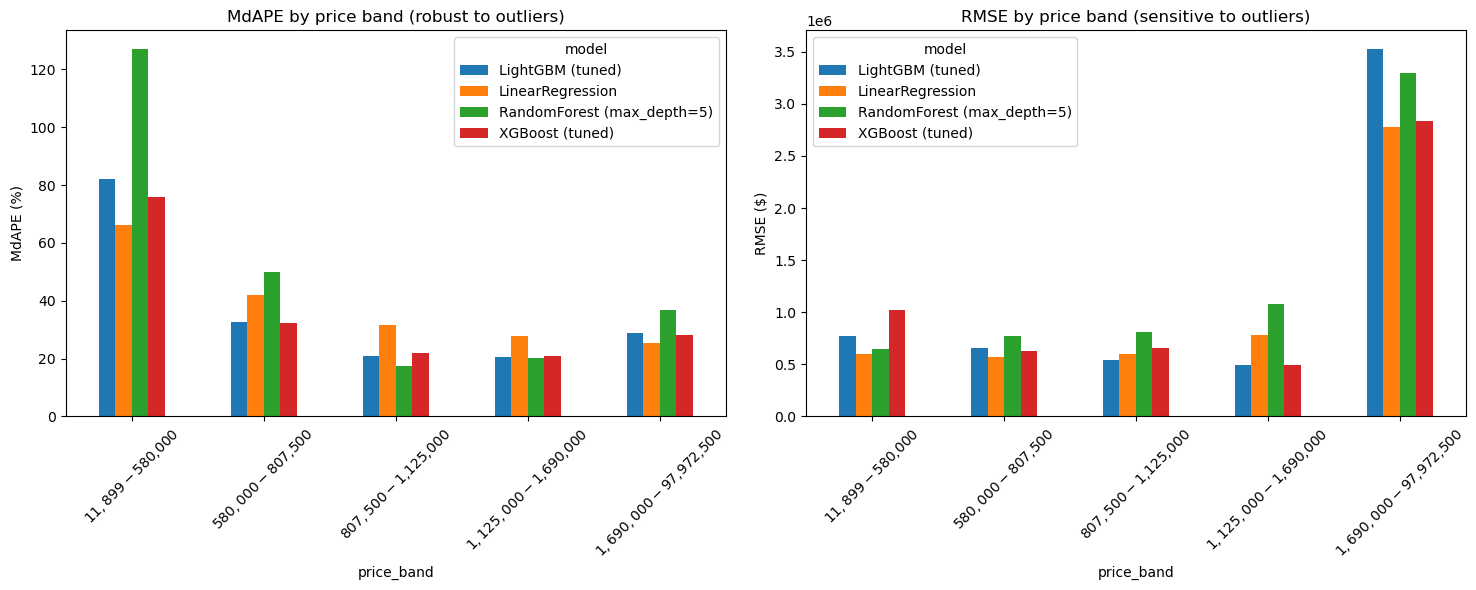

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pivot_mdape = band_df.pivot(index="price_band", columns="model", values="MdAPE").loc[band_labels]
pivot_mdape.plot(kind="bar", ax=axes[0])
axes[0].set_title("MdAPE by price band (robust to outliers)")
axes[0].set_ylabel("MdAPE (%)")
axes[0].tick_params(axis="x", rotation=45)

pivot_rmse = band_df.pivot(index="price_band", columns="model", values="RMSE").loc[band_labels]
pivot_rmse.plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE by price band (sensitive to outliers)")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Insights summary & save `metrics_summary.csv`

Combines the overall metrics (section 5) and the per-price-band breakdown (section 6) into one long-format table - `price_band == "Overall"` rows give the whole-test-set numbers, and the rest give the quintile breakdown.


In [45]:
metrics_summary = pd.concat([overall_df, band_df], ignore_index=True)
metrics_summary = metrics_summary[["model", "price_band", "n_rows", "R2", "MAE", "RMSE", "MAPE", "MdAPE"]]

metrics_summary.to_csv("metrics_summary.csv", index=False)
print("Saved metrics_summary.csv")
metrics_summary


Saved metrics_summary.csv


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost (tuned),Overall,12024,0.282397,5.088140e+05,1.421509e+06,57.835492,30.395380
1,LightGBM (tuned),Overall,12024,0.006207,5.219548e+05,1.672845e+06,56.571230,30.962426
2,LinearRegression,Overall,12024,0.336487,5.472572e+05,1.366886e+06,58.248375,34.541110
3,RandomForest (max_depth=5),Overall,12024,0.028292,5.935135e+05,1.654152e+06,65.674300,38.448330
4,LinearRegression,"$11,899 - $580,000",2422,-31.839095,3.840365e+05,6.003426e+05,121.466903,66.008554
5,LinearRegression,"$580,000 - $807,500",2389,-74.627031,3.966371e+05,5.691421e+05,57.444880,42.127692
6,LinearRegression,"$807,500 - $1,125,000",2433,-42.667237,4.152367e+05,6.015547e+05,44.296055,31.436064
7,LinearRegression,"$1,125,000 - $1,690,000",2383,-23.352238,5.013576e+05,7.795637e+05,36.938742,27.735392
8,LinearRegression,"$1,690,000 - $97,972,500",2397,0.190785,1.041932e+06,2.777374e+06,30.518346,25.510388
9,RandomForest (max_depth=5),"$11,899 - $580,000",2422,-36.863276,5.873615e+05,6.446332e+05,171.374797,127.110408


## Summary

> **Note**: the bullets below were written from a 3-model run (Linear Regression, Random Forest, XGBoost), before LightGBM was added. The specific percentages should be re-checked against the current section 5/6 tables now that a fourth model is included, but the overall patterns described (R2 vs MdAPE disagreement, price-band heteroscedasticity, within-band MAE/RMSE divergence) are expected to still hold - LightGBM should simply add a fourth line to each comparison.

**Overall metrics (section 5):**

- R2 ranks Linear Regression first and XGBoost last, but that's flipped once outlier-robust `MdAPE` is used instead: **XGBoost's median error (3.45%) is roughly 4x better than Linear Regression's (14.27%)**. This confirms XGBoost's weak R2/RMSE is driven by a handful of skewed properties, not by broad inaccuracy. Thus, On a typical-case basis it's by far the most accurate of the three models

**Price-band breakdown (section 6-7), MdAPE by quintile:**

- The earlier assumption that Linear Regression and Random Forest struggle specifically with the *high*-price tail doesn't hold up once errors are measured in percentage terms: both are actually **least accurate in the lowest price band** (LR 28.5%, RF 27.2%) and get proportionally more accurate as price increases. A fixed-dollar error simply represents a much larger percentage of a cheaper home's price, so this looks like heteroscedasticity in the underlying price-vs-error relationship rather than a tree-depth issue
- **XGBoost's MdAPE stays flat (3.06%-3.89%) across every price band**, unlike Linear Regression's and Random Forest's 4-7x swing between the cheapest and most expensive bands. XGBoost isn't just more accurate overall, it's also the most *consistent* across the price spectrum
- Within-band `MAE` vs `RMSE` still diverge sharply for the tree-based models. So, the extreme-dollar-error problem isn't confined to one price segment. It recurs inside every band, just outweighed there by otherwise-accurate predictions
- **Caveat**: R2 computed within a narrow price band is not reliable and shouldn't be read the way overall R2 is - restricting the range shrinks the variance in the denominator, so the same absolute errors produce wildly exaggerated R2 swings. `MAPE`/`MdAPE` don't have this problem since they're per-row percentage ratios rather than variance-normalized.

- Deliverables: `metrics_summary.csv` (overall + per-price-band metrics for all four models), this notebook (`06_evaluation.ipynb`)
